In [1]:
import torch

SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# 0. Choosing "teacher" model

In [2]:
checkpoint = "bert-base-uncased"
task_name  = "mrpc"

# 1. Loading our mrpc part of the GLUE dataset

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", task_name)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating test split: 100%|██████████| 1725/1725 [00:00<00:00, 814313.38 examples/s]


In [4]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1725
    })
})

In [5]:
raw_datasets['train']

Dataset({
    features: ['sentence1', 'sentence2', 'label', 'idx'],
    num_rows: 3668
})

In [6]:
from datasets import DatasetDict

In [7]:
raw_datasets = DatasetDict({
    "train": raw_datasets['train'],
    "validation": raw_datasets['validation'],
    "test": raw_datasets['test']
})

In [8]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1725
    })
})

In [9]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0]

{'sentence1': 'Amrozi accused his brother , whom he called " the witness " , of deliberately distorting his evidence .',
 'sentence2': 'Referring to him as only " the witness " , Amrozi accused his brother of deliberately distorting his evidence .',
 'label': 1,
 'idx': 0}

In [10]:
raw_train_dataset[5]['sentence1'], raw_train_dataset[5]['sentence2']

('Revenue in the first quarter of the year dropped 15 percent from the same period a year earlier .',
 "With the scandal hanging over Stewart 's company , revenue the first quarter of the year dropped 15 percent from the same period a year earlier .")

In [11]:
raw_train_dataset[5]['label']

1

In [12]:
raw_train_dataset[5]['idx']

5

In [13]:
raw_train_dataset.features

{'sentence1': Value('string'),
 'sentence2': Value('string'),
 'label': ClassLabel(names=['not_equivalent', 'equivalent']),
 'idx': Value('int32')}

# 2. Preprocess

In [14]:
def tokenize_function(example):
    return tokenizer(example["sentence1"], example["sentence2"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

Map: 100%|██████████| 1725/1725 [00:00<00:00, 36998.16 examples/s]


DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1725
    })
})

# 3. Preparing for Training

In [15]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [16]:
tokenized_datasets = tokenized_datasets.remove_columns(["sentence1", "sentence2", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

['labels', 'input_ids', 'token_type_ids', 'attention_mask']

In [17]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_datasets["train"], shuffle=True, batch_size=32, collate_fn=data_collator
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"], batch_size=32, collate_fn=data_collator
)

eval_dataloader = DataLoader(
    tokenized_datasets["test"], batch_size=32, collate_fn=data_collator
)

In [18]:
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([32]),
 'input_ids': torch.Size([32, 100]),
 'token_type_ids': torch.Size([32, 100]),
 'attention_mask': torch.Size([32, 100])}

# 4. Loading model

In [19]:
import sys
sys.path.insert(0, '../')

In [20]:
import os
os.environ["WANDB_DISABLED"] = "true"

In [21]:
from Bert_model.modeling_bert import BertForSequenceClassification

In [22]:
# id2label, label2id dicts for the outputs for the model
labels = tokenized_datasets["train"].features["labels"].names
num_labels = len(labels)
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label

In [23]:
model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [24]:
model.set_use_module_grafting(False)
model.set_use_scc_status(False)

In [25]:
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(1.2996, grad_fn=<NllLossBackward0>) torch.Size([32, 2])


### Loading Trained Weights

In [26]:
path = './Techer Fine-Tune/weights/'

In [27]:
best_weight = torch.load(path + f'bert-{task_name}.pt')

In [28]:
model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [29]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

device

device(type='cuda')

In [30]:
from train_eval_func import eval_loop

In [31]:
eval_loop(model, eval_dataloader, task_name, device)[0]

{'accuracy': 0.8359420289855073, 'f1': 0.8813417190775681}

# 5. Similarity Analysis

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
from CKA import CudaCKA
from tqdm import tqdm

In [33]:
cuda_cka = CudaCKA(device)

In [34]:
def extract_cls_token_embedding(hidden_states):
    only_cls_embeddings = []
    for hs in hidden_states:
        cls_embedding = hs[:,0,:]
        only_cls_embeddings.append(cls_embedding)
        
    return only_cls_embeddings

def combine_rep_attOut(reps, atts_out):
    combined_list = []
    for r, a in zip(reps, atts_out):
        combined_list.append(a)
        combined_list.append(r)
    
    return combined_list

def CKA_pairwise_helper(sublayer_outs, only_cls_token=False, is_att = False):
    if is_att:
        sublayer_outs = flatten_atts(sublayer_outs)
    elif only_cls_token:
        sublayer_outs = extract_cls_token_embedding(sublayer_outs)
        
    # shape [batch_size, dim1 * .... * dim_n]
    flattened_out_list = []
    for sublayer_out in sublayer_outs:
        flattened_out = torch.flatten(sublayer_out, start_dim=1)
        flattened_out_list.append(flattened_out)
    
    layer_similarity  = []
    layers_similarity = []
    
    for out_1 in flattened_out_list:
        for out_2 in flattened_out_list:
            cka_value = cuda_cka.linear_CKA(out_1, out_2)
            layer_similarity.append(cka_value.detach().cpu())

        layers_similarity.append(np.array(layer_similarity))
        layer_similarity = []
    
    return np.array(layers_similarity)

def CKA_pairwise(model, dataloader, device, only_cls_token=False, max_iter=float("Inf")):
    model.set_use_module_grafting(False)
    model.set_use_scc_status(False)
    
    n_batch = len(dataloader)
    reps_similarity, atts_similarity = None, None

    progress_bar = tqdm(range(min(n_batch, max_iter)),desc="CKA Evaluation")
    
    model.eval()
    for step, batch in enumerate(dataloader):
        if step == max_iter:
            break
            
        batch = {k: v.to(device) for k, v in batch.items()}
        
        # get model output
        with torch.no_grad():
            output = model(**batch)
        loss = output.loss
        reps = output.hidden_states['hidden_states'][1:] # omitting embedding output
        # atts = output.attentions
        
        # similarity estimation
        if reps_similarity is None:
            reps_similarity = CKA_pairwise_helper(reps, only_cls_token)
            # atts_similarity = CKA_pairwise_helper(atts, only_cls_token, is_att=True)
        else:
            reps_similarity =+ CKA_pairwise_helper(reps, only_cls_token)
            # atts_similarity =+ CKA_pairwise_helper(atts, only_cls_token, is_att=True)
        
        progress_bar.update(1)
                
    # averaging
    reps_similarity = reps_similarity / n_batch
    # atts_similarity = atts_similarity / n_batch
    
    # return reps_similarity, atts_similarity
    return reps_similarity

### CLS Token Only

In [35]:
cls_reps_similarity = CKA_pairwise(model, val_dataloader, device, only_cls_token=True, max_iter=float("Inf"))

CKA Evaluation: 100%|██████████| 13/13 [00:01<00:00, 11.84it/s]


Text(50.722222222222214, 0.5, 'Layer')

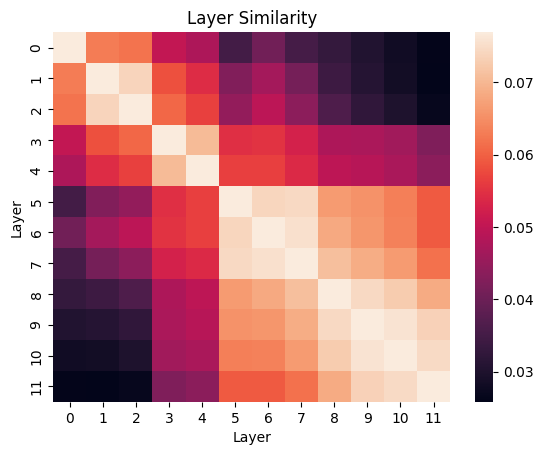

In [36]:
title = "Layer Similarity"
plt.title(title)
sn.heatmap(data = cls_reps_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

### All Tokens Considered

In [37]:
reps_similarity = CKA_pairwise(model, val_dataloader, device, only_cls_token=False, max_iter=float("Inf"))

CKA Evaluation: 100%|██████████| 13/13 [00:01<00:00,  9.44it/s]


Text(50.722222222222214, 0.5, 'Layer')

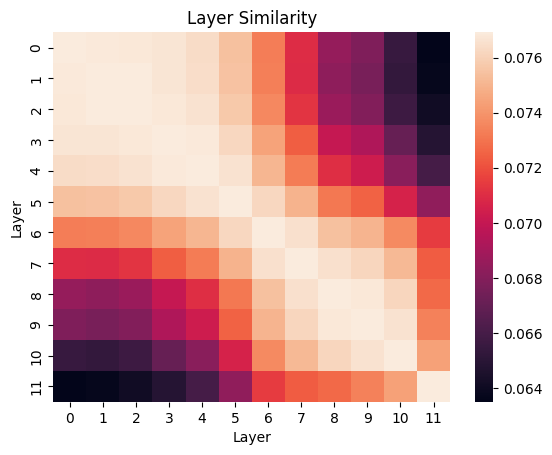

In [38]:
title = "Layer Similarity"
plt.title(title)
sn.heatmap(data = reps_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

# 6. Testing Reorder Heads

### Importance Score

In [39]:
def compute_importance_score(model, eval_dataloader, compute_importance=True, 
                             head_mask=None, int_mask=None, train=False, optimizer=None,
                             lr_scheduler=None, desc="Iteration", max_iter=float("Inf")):
    n_layers  = model.bert.config.num_hidden_layers
    n_heads   = model.bert.config.num_attention_heads
    n_int_dim = model.bert.config.intermediate_size
    
    head_importance = torch.zeros(n_layers, n_heads).to(device)
    int_importance  = torch.zeros(n_layers, n_int_dim).to(device)
    
    if int_mask is None and compute_importance:
        int_mask = torch.ones(n_layers, n_int_dim).to(device)
        int_mask.requires_grad_(requires_grad=True)
    elif compute_importance:
        int_mask = int_mask.clone().detach()
        int_mask.requires_grad_(requires_grad=True)
        
    if head_mask is None and compute_importance:
        head_mask = torch.ones(n_layers, n_heads).to(device)
        head_mask.requires_grad_(requires_grad=True)
    elif compute_importance:
        head_mask = head_mask.clone().detach()
        head_mask.requires_grad_(requires_grad=True)
        
    preds = None
    labels = None
    tot_tokens = 0.0
    
    if train:
        optimizer.zero_grad()
    
    total_loss = 0
    n_batches  = len(eval_dataloader)
    progress_bar = tqdm(range(min(n_batches, max_iter)),desc=desc)
    model.train()
    for step, batch in enumerate(eval_dataloader):
        if step == max_iter:
            break
            
        label_ids = batch.labels
        input_mask = batch.attention_mask
        
        batch = {k: v.to(device) for k, v in batch.items()}
        
        outputs = model(**batch, head_mask=head_mask, int_mask=int_mask)
        loss, logits, all_attentions = (outputs.loss, outputs.logits, outputs.attentions)
        total_loss = float(loss)
        loss.backward()  # Backpropagate to populate the gradients in the head mask
        if train:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            
            optimizer.step()
            optimizer.zero_grad()
            if lr_scheduler is not None:
                lr_scheduler.step()
        
        if compute_importance:
            int_importance  += int_mask.grad.abs().detach()
            head_importance += head_mask.grad.abs().detach()
        
        # Also store our logits/labels if we want to compute metrics afterwards
        if preds is None:
            preds = logits.detach().cpu()
            labels = label_ids
        else:
            preds = torch.cat((preds, logits.detach().cpu()), 0)
            labels = torch.cat((labels, label_ids), 0)

        tot_tokens += input_mask.float().detach().sum().data
        progress_bar.update(1)
    
    avg_train_loss = total_loss / n_batches
    
    if compute_importance:
        # Normalize
        head_importance /= tot_tokens
        int_importance /= tot_tokens
        
        # np.save(os.path.join(output_dir, "head_importance.npy"), head_importance.detach().cpu().numpy())
        # np.save(os.path.join(output_dir, "int_importance.npy"), int_importance.detach().cpu().numpy())
    
    return head_importance, int_importance, preds, labels, avg_train_loss

### Reording Attention Head and Intermediate Dimension Connection Functions

In [40]:
def reorder_heads(idx, layer):
    n = model.bert.encoder.layer[0].attention.self.num_attention_heads
    a = model.bert.encoder.layer[0].attention.self.attention_head_size

    index = torch.arange(n*a).reshape(n, a)[idx].view(-1).contiguous().long()

    def reorder_head_matrix(linearLayer, index, dim=0):
        index = index.to(device)
        W = linearLayer.weight.index_select(dim, index).clone().detach()
        if linearLayer.bias is not None:
            if dim == 1:
                b = linearLayer.bias.clone().detach()
            else:
                b = linearLayer.bias[index].clone().detach()

        linearLayer.weight.requires_grad = False
        linearLayer.weight.copy_(W.contiguous())
        linearLayer.weight.requires_grad = True
        if linearLayer.bias is not None:
            linearLayer.bias.requires_grad = False
            linearLayer.bias.copy_(b.contiguous())
            linearLayer.bias.requires_grad = True

    reorder_head_matrix(model.bert.encoder.layer[layer].attention.self.query, index)
    reorder_head_matrix(model.bert.encoder.layer[layer].attention.self.key, index)
    reorder_head_matrix(model.bert.encoder.layer[layer].attention.self.value, index)
    reorder_head_matrix(model.bert.encoder.layer[layer].attention.output.dense, index, dim=1)

In [41]:
def reorder_neurons(self, index, dim=0):
    index = index.to(self.dense.weight.device)
    W = self.dense.weight.index_select(dim, index).clone().detach()
    if self.dense.bias is not None:
        if dim == 1:
            b = self.dense.bias.clone().detach()
        else:
            b = self.dense.bias[index].clone().detach()
    self.dense.weight.requires_grad = False
    self.dense.weight.copy_(W.contiguous())
    self.dense.weight.requires_grad = True
    if self.dense.bias is not None:
        self.dense.bias.requires_grad = False
        self.dense.bias.copy_(b.contiguous())
        self.dense.bias.requires_grad = True

In [42]:
model.bert.encoder.layer[0].attention

BertAttention(
  (self): BertSelfAttention(
    (query): Linear(in_features=768, out_features=768, bias=True)
    (key): Linear(in_features=768, out_features=768, bias=True)
    (value): Linear(in_features=768, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (output): BertSelfOutput(
    (dense): Linear(in_features=768, out_features=768, bias=True)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
)

In [43]:
model.bert.encoder.layer[0].attention.self.query.weight.shape

torch.Size([768, 768])

In [44]:
def merge_bert_layers(model, layer1_idx=1, layer2_idx=2):
    """
    Merge two BERT layers by concatenating their components.
    Creates a new layer with double the parameters.
    """
    
    layer1 = model.bert.encoder.layer[layer1_idx]
    layer2 = model.bert.encoder.layer[layer2_idx]
    
    # Create a new layer (copy of layer1)
    from copy import deepcopy
    merged_layer = deepcopy(layer1)
    
    # Merge attention query, key, value weights
    # Concatenate along output dimension (dim=0)
    def concat_linear_layers(linear1, linear2):
        """Concatenate two linear layers along output dimension"""
        new_weight = torch.cat([linear1.weight, linear2.weight], dim=0)
        new_bias = torch.cat([linear1.bias, linear2.bias], dim=0) if linear1.bias is not None else None
        
        new_linear = torch.nn.Linear(
            linear1.in_features,
            linear1.out_features + linear2.out_features,
            bias=(linear1.bias is not None)
        ).to(linear1.weight.device)
        
        new_linear.weight.data = new_weight
        if new_bias is not None:
            new_linear.bias.data = new_bias
        
        return new_linear
    
    # Merge attention components
    merged_layer.attention.self.query = concat_linear_layers(
        layer1.attention.self.query,
        layer2.attention.self.query
    )
    merged_layer.attention.self.key = concat_linear_layers(
        layer1.attention.self.key,
        layer2.attention.self.key
    )
    merged_layer.attention.self.value = concat_linear_layers(
        layer1.attention.self.value,
        layer2.attention.self.value
    )
    
    # Update number of attention heads
    merged_layer.attention.self.num_attention_heads = (
        layer1.attention.self.num_attention_heads + 
        layer2.attention.self.num_attention_heads
    )
    
    # Merge attention output dense layer (input dimension doubles)
    merged_output_weight = torch.cat([
        layer1.attention.output.dense.weight,
        layer2.attention.output.dense.weight
    ], dim=1)
    
    merged_layer.attention.output.dense = torch.nn.Linear(
        merged_output_weight.shape[1],
        layer1.attention.output.dense.out_features,
        bias=(layer1.attention.output.dense.bias is not None)
    ).to(merged_output_weight.device)
    
    merged_layer.attention.output.dense.weight.data = merged_output_weight
    if layer1.attention.output.dense.bias is not None:
        # Average the biases
        merged_layer.attention.output.dense.bias.data = (
            layer1.attention.output.dense.bias + layer2.attention.output.dense.bias
        ) / 2
    
    # Merge FFN intermediate layer
    merged_layer.intermediate.dense = concat_linear_layers(
        layer1.intermediate.dense,
        layer2.intermediate.dense
    )
    
    # Merge FFN output layer (input dimension doubles)
    merged_ffn_output_weight = torch.cat([
        layer1.output.dense.weight,
        layer2.output.dense.weight
    ], dim=1)
    
    merged_layer.output.dense = torch.nn.Linear(
        merged_ffn_output_weight.shape[1],
        layer1.output.dense.out_features,
        bias=(layer1.output.dense.bias is not None)
    ).to(merged_ffn_output_weight.device)
    
    merged_layer.output.dense.weight.data = merged_ffn_output_weight
    if layer1.output.dense.bias is not None:
        merged_layer.output.dense.bias.data = (
            layer1.output.dense.bias + layer2.output.dense.bias
        ) / 2
    
    return merged_layer

In [45]:
merged = merge_bert_layers(model, 4, 5)

In [46]:
model.bert.encoder.layer[4] = merged
del model.bert.encoder.layer[5]

In [47]:
model.bert.encoder.layer[4].attention.self.query.weight.shape

torch.Size([1536, 768])

In [49]:
768 + 768

1536

In [52]:
eval_loop(model, eval_dataloader, task_name, device)[0]

RuntimeError: shape '[32, 78, 768]' is invalid for input of size 3833856